  # BookSum — EDA & Data Preprocessing Pipeline
  Project: Extractive vs Abstractive Summarization for Books
  Course : IT469 — Human Language Technologies
  Team   : Group 11

Sections:
 1. LOAD DATASET
 2. EDA (Exploratory Data Analysis)
 3. PREPROCESSING PIPELINE
 4. CHUNKING
 5. POST-PROCESSING VALIDATION
 6. SAVE PROCESSED DATA
 7. DistilBERT Extractive Summarization

**SETUP & IMPORTS**

This section loads all required libraries for the project.
We use pandas and numpy for data manipulation, matplotlib and seaborn
for visualization, nltk for text tokenization, and the HuggingFace
datasets library to load BookSum directly.

In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
import json
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from datasets import load_dataset

print('All imports successful')


All imports successful


## 1.LOAD DATASET


We load the BookSum dataset (kmfoda/booksum) from HuggingFace and
convert each split into a pandas DataFrame. The dataset contains
9,600 training rows, 1,484 validation rows, and 1,431 test rows,
for a total of 12,515 chapter-summary pairs.

In [ ]:
print('\nLoading BookSum dataset from HuggingFace...')
dataset = load_dataset('kmfoda/booksum')

df_train = pd.DataFrame(dataset['train'])
df_val   = pd.DataFrame(dataset['validation'])
df_test  = pd.DataFrame(dataset['test'])

print(f'\n Dataset loaded!')
print(f'  Train:      {len(df_train):,} rows')
print(f'  Validation: {len(df_val):,} rows')
print(f'  Test:       {len(df_test):,} rows')
print(f'  Total:      {len(df_train) + len(df_val) + len(df_test):,} rows')


Loading BookSum dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/295M [00:00<?, ?B/s]

dev.csv:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/43.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9600 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1484 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1431 [00:00<?, ? examples/s]


 Dataset loaded!
  Train:      9,600 rows
  Validation: 1,484 rows
  Test:       1,431 rows
  Total:      12,515 rows


## 2.EDA (Exploratory Data Analysis)

### 2.1 First Look

Before any processing, we inspect the dataset structure to understand
its columns, data types, and missing values. We found that 'content'
is entirely empty (100%) and 'summary_analysis' is missing in 44.75%
of rows. Neither affects our core columns: chapter and summary_text,
which have zero missing values.

In [ ]:

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

print('\n=== COLUMNS ===')
print(df_train.columns.tolist())

print('\n=== DTYPES ===')
print(df_train.dtypes)

print('\n=== SHAPE ===')
print(df_train.shape)

print('\n=== FIRST 2 ROWS (key columns) ===')
print(df_train[['bid', 'book_id', 'source', 'is_aggregate',
                 'chapter_length', 'summary_length']].head(2))

print('\n=== MISSING VALUES ===')
missing     = df_train.isnull().sum()
missing_pct = (missing / len(df_train) * 100).round(2)
missing_df  = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print(missing_df[missing_df['missing_count'] > 0])
print(f'\nColumns with zero missing values: {(missing == 0).sum()}')



=== COLUMNS ===
['bid', 'is_aggregate', 'source', 'chapter_path', 'summary_path', 'book_id', 'summary_id', 'content', 'summary', 'chapter', 'chapter_length', 'summary_name', 'summary_url', 'summary_text', 'summary_analysis', 'summary_length', 'analysis_length']

=== DTYPES ===
bid                   int64
is_aggregate           bool
source               object
chapter_path         object
summary_path         object
book_id              object
summary_id           object
content              object
summary              object
chapter              object
chapter_length      float64
summary_name         object
summary_url          object
summary_text         object
summary_analysis     object
summary_length      float64
analysis_length     float64
dtype: object

=== SHAPE ===
(9600, 17)

=== FIRST 2 ROWS (key columns) ===
     bid                                book_id      source  is_aggregate  \
0  27681  The Last of the Mohicans.chapters 1-2  cliffnotes          True   
1  27681     Th



> The dataset contains 17 columns, of which 13 have no missing values.
The two columns relevant to our task — chapter and summary_text —
are complete with zero missing values. The column 'content' is entirely
empty and will be ignored. The missing values in 'summary_analysis'
(44.75%) are not a concern since we only use summary_text as the
reference for evaluation.

### 2.2 COLUMN-BY-COLUMN Exploration


**Key columns for our project:**

   chapter        → model input  (long text)

   summary_text   → model output (reference summary)

   source         → where the summary came from

   is_aggregate   → True = covers multiple chapters (should be removed)

   chapter_length → pre-computed token count of chapter

  summary_length → pre-computed token count of summary
  
   summary_analysis → additional analysis section (NOT a pure summary)


#### 2.2.1 is_aggregated


The is_aggregate column indicates whether a row covers a single chapter
(False) or multiple chapters combined (True). We found that 16.4% of
training rows are aggregate. Since our project focuses on chapter-level
summarization, all aggregate rows will be removed in preprocessing.


=== is_aggregate Distribution ===
              count  percentage
is_aggregate                   
False          8027       83.61
True           1573       16.39

💡 16.4% are aggregate — will be removed in preprocessing.


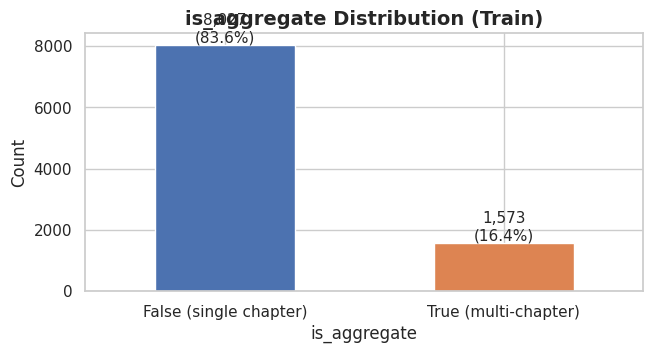

In [ ]:
print('\n=== is_aggregate Distribution ===')
counts = df_train['is_aggregate'].value_counts()
pcts   = df_train['is_aggregate'].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': counts, 'percentage': pcts.round(2)}))
print(f'\n💡 {pcts[True]:.1f}% are aggregate — will be removed in preprocessing.')

fig, ax = plt.subplots(figsize=(7, 4))
counts.plot(kind='bar', ax=ax,
            color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
ax.set_title('is_aggregate Distribution (Train)', fontsize=14, fontweight='bold')
ax.set_xticklabels(['False (single chapter)', 'True (multi-chapter)'], rotation=0)
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}\n({p.get_height()/len(df_train)*100:.1f}%)',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom', fontsize=11
    )
plt.tight_layout(pad=2.0)
plt.savefig('fig_01_is_aggregate.png', dpi=120)
plt.show()



> 16.4% of training rows (1,573 rows) are aggregate entries covering
multiple chapters. These will be removed in preprocessing since our
project focuses on chapter-level summarization. The remaining 83.6%
(8,027 rows) are single-chapter entries suitable for our task.

#### 2.2.2 source

The dataset contains summaries from 8 different online sources:
cliffnotes, sparknotes, gradesaver, shmoop, novelguide, pinkmonkey,
thebestnotes, and bookwolf. Each source has a different writing style
and summary length, which may affect model evaluation later.


=== Summary Sources ===
              count  percentage
source                         
shmoop         2832       29.50
gradesaver     1452       15.12
sparknotes     1346       14.02
cliffnotes     1274       13.27
novelguide     1191       12.41
pinkmonkey     1009       10.51
thebestnotes    294        3.06
bookwolf        202        2.10

Total unique sources: 8


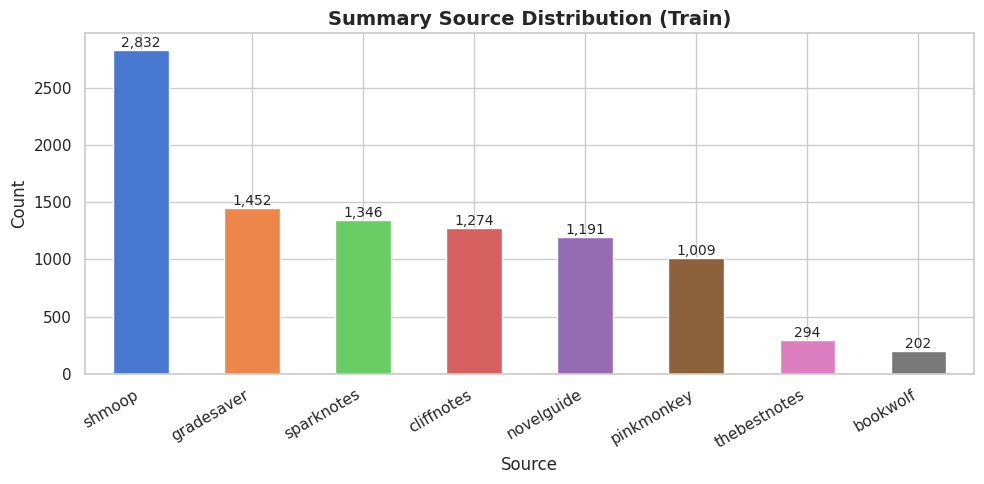

In [ ]:
print('\n=== Summary Sources ===')
src_counts = df_train['source'].value_counts()
src_pcts   = df_train['source'].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': src_counts, 'percentage': src_pcts.round(2)}))
print(f'\nTotal unique sources: {df_train["source"].nunique()}')

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette('muted', n_colors=len(src_counts))
src_counts.plot(kind='bar', ax=ax, color=palette, edgecolor='white')
ax.set_title('Summary Source Distribution (Train)', fontsize=14, fontweight='bold')
ax.set_xlabel('Source')
ax.set_ylabel('Count')
ax.set_xticklabels(src_counts.index, rotation=30, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('fig_02_sources.png', dpi=120)
plt.show()

> Shmoop is the largest contributor
with 2,832 rows (29.5%), followed by gradesaver (1,452) and sparknotes
(1,346). bookwolf is the smallest source with only 294 rows (3.1%).
This imbalance means the dataset is not equally representative of
all sources.

#### 2.2.3 Books

The training set covers 170 unique books, with an average of 56.5
chapters per book. The distribution is highly skewed — some books
have only 1 chapter entry while others have up to 266. The top 15
books by chapter count are all fiction (e.g. Middlemarch, Emma,
Frankenstein), revealing a genre imbalance in the dataset.


=== Unique Books ===
Unique book IDs (train): 170
Unique book IDs (val):   22
Unique book IDs (test):  21

Chapters per book:
count    170.0
mean      56.5
std       59.3
min        1.0
25%       12.2
50%       36.5
75%       77.5
max      266.0
dtype: float64


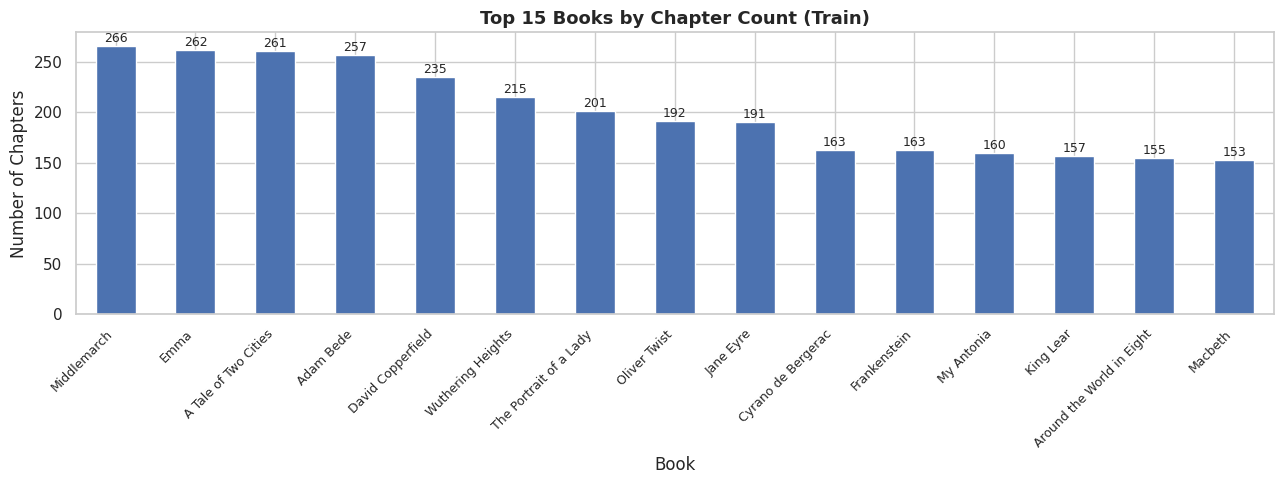

In [ ]:

print('\n=== Unique Books ===')
print(f'Unique book IDs (train): {df_train["bid"].nunique():,}')
print(f'Unique book IDs (val):   {df_val["bid"].nunique():,}')
print(f'Unique book IDs (test):  {df_test["bid"].nunique():,}')

chapters_per_book = df_train.groupby('bid').size()
print('\nChapters per book:')
print(chapters_per_book.describe().round(1))

bid_to_name = df_train.groupby('bid')['book_id'].first()

top_books = df_train.groupby('bid').size().sort_values(ascending=False).head(15)
top_books.index = top_books.index.map(
    lambda x: bid_to_name[x].split('.')[0][:25]
)

fig, ax = plt.subplots(figsize=(13, 5))
top_books.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Top 15 Books by Chapter Count (Train)', fontsize=13, fontweight='bold')
ax.set_xlabel('Book')
ax.set_ylabel('Number of Chapters')
ax.set_xticklabels(top_books.index, rotation=45, ha='right', fontsize=9)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 1,
            f'{int(p.get_height())}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('fig_03_top_books.png', dpi=120)
plt.show()

### 2.3 Length & Distribution Analysis


We compute word counts for all chapters and summaries to understand
the length distribution. The median chapter length is 2,934 words,
far exceeding BERT's limit of ~380 words. Specifically, 96% of
chapters exceed the BERT limit and 48.6% exceed the LED limit of
~3,000 words. This confirms that hierarchical chunking is required
for all transformer-based models.


=== Chapter Word Count Stats ===
count      9600.0
mean       4021.0
std        4413.0
min          48.0
25%        1692.0
50%        2934.0
75%        4712.0
max      114455.0
Name: chapter_words, dtype: float64

=== Summary Word Count Stats ===
count    9600.0
mean      377.0
std       332.0
min         2.0
25%       171.0
50%       283.0
75%       467.0
max      4852.0
Name: summary_words, dtype: float64


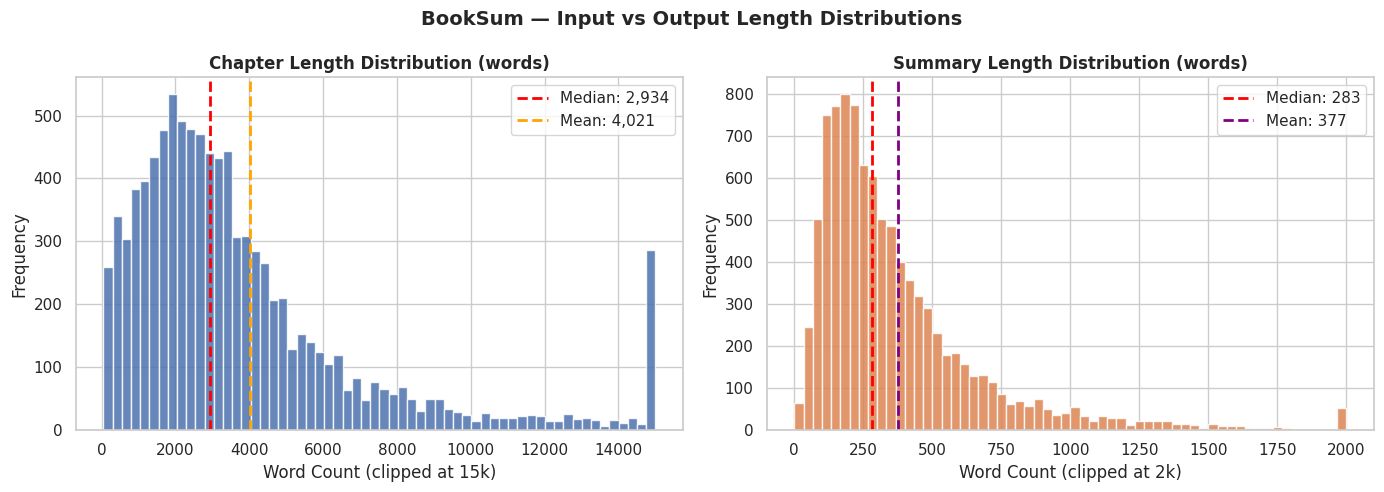


=== Word Count Percentiles ===
Percentile  Chapter Words  Summary Words
       p10            835            109
       p25           1691            171
       p50           2934            283
       p75           4712            467
       p90           8036            740
       p95          11783           1008
       p99          21382           1646

⚠️  BERT max ≈ 512 tokens  ≈  ~380 words
   LED  max ≈ 4096 tokens ≈  ~3000 words
   > 380 words  (BERT): 9,216/9,600 = 96.0%
   > 3000 words (LED):  4,662/9,600 = 48.6%
   → Confirms the need for hierarchical chunking.


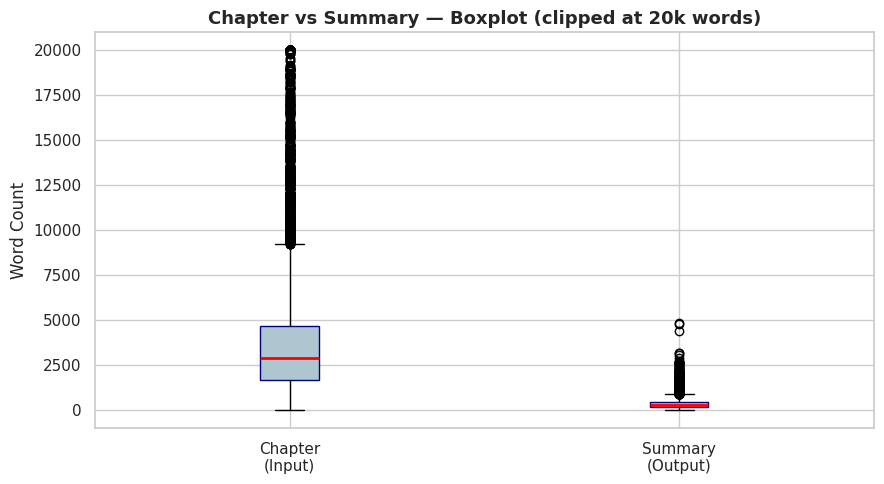

In [ ]:

# Compute word counts
df_train['chapter_words'] = df_train['chapter'].str.split().str.len()
df_train['summary_words'] = df_train['summary_text'].str.split().str.len()

print('\n=== Chapter Word Count Stats ===')
print(df_train['chapter_words'].describe().round(0))

print('\n=== Summary Word Count Stats ===')
print(df_train['summary_words'].describe().round(0))

# Histogram side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_train['chapter_words'].clip(upper=15000), bins=60,
             color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(df_train['chapter_words'].median(), color='red',
                linestyle='--', linewidth=2,
                label=f'Median: {df_train["chapter_words"].median():,.0f}')
axes[0].axvline(df_train['chapter_words'].mean(), color='orange',
                linestyle='--', linewidth=2,
                label=f'Mean: {df_train["chapter_words"].mean():,.0f}')
axes[0].set_title('Chapter Length Distribution (words)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Word Count (clipped at 15k)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df_train['summary_words'].clip(upper=2000), bins=60,
             color='#DD8452', edgecolor='white', alpha=0.85)
axes[1].axvline(df_train['summary_words'].median(), color='red',
                linestyle='--', linewidth=2,
                label=f'Median: {df_train["summary_words"].median():,.0f}')
axes[1].axvline(df_train['summary_words'].mean(), color='purple',
                linestyle='--', linewidth=2,
                label=f'Mean: {df_train["summary_words"].mean():,.0f}')
axes[1].set_title('Summary Length Distribution (words)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Word Count (clipped at 2k)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('BookSum — Input vs Output Length Distributions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04_length_distributions.png', dpi=120)
plt.show()

# Percentile table
percentiles  = [10, 25, 50, 75, 90, 95, 99]
ch_pct  = np.percentile(df_train['chapter_words'].dropna(),  percentiles).astype(int)
sum_pct = np.percentile(df_train['summary_words'].dropna(), percentiles).astype(int)

pct_df = pd.DataFrame({
    'Percentile':     [f'p{p}' for p in percentiles],
    'Chapter Words':  ch_pct,
    'Summary Words':  sum_pct
})
print('\n=== Word Count Percentiles ===')
print(pct_df.to_string(index=False))

total = len(df_train)
print(f'\n⚠️  BERT max ≈ 512 tokens  ≈  ~380 words')
print(f'   LED  max ≈ 4096 tokens ≈  ~3000 words')
print(f'   > 380 words  (BERT): {(df_train["chapter_words"]>380).sum():,}/{total:,}'
      f' = {(df_train["chapter_words"]>380).mean()*100:.1f}%')
print(f'   > 3000 words (LED):  {(df_train["chapter_words"]>3000).sum():,}/{total:,}'
      f' = {(df_train["chapter_words"]>3000).mean()*100:.1f}%')
print('   → Confirms the need for hierarchical chunking.')

# Boxplot
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(
    [df_train['chapter_words'].clip(upper=20000).dropna(),
     df_train['summary_words'].clip(upper=20000).dropna()],
    labels=['Chapter\n(Input)', 'Summary\n(Output)'],
    patch_artist=True,
    boxprops=dict(facecolor='#AEC6CF', color='navy'),
    medianprops=dict(color='red', linewidth=2)
)
ax.set_title('Chapter vs Summary — Boxplot (clipped at 20k words)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Word Count')
plt.tight_layout()
plt.savefig('fig_05_boxplot.png', dpi=120)
plt.show()



> The median chapter length is 2,934 words and the mean is 4,021 words. The gap between mean and median confirms a right-skewed distribution
with some very long chapters pulling the mean upward. For summaries,
the median is 283 words and the mean is 377 words. Critically, 96%
of chapters exceed BERT's input limit (~380 words) and 48.6% exceed
LED's limit (~3,000 words), confirming that chunking is necessary
for nearly all samples in the dataset.

### 2.4 Source Analysis


We compare summary length and compression across sources. gradesaver
produces the longest summaries (avg 502 words) while bookwolf produces
the shortest (avg 194 words). This two-fold difference in summary
length means that ROUGE scores may vary significantly depending on
which source the reference summary comes from.


=== Stats Per Source ===
              count  avg_chapter_words  avg_summary_words  median_summary
source                                                                   
bookwolf        202               3597                194             166
cliffnotes     1274               5018                399             284
gradesaver     1452               5521                502             348
novelguide     1191               3866                287             220
pinkmonkey     1009               2819                319             259
shmoop         2832               3171                416             334
sparknotes     1346               4572                309             234
thebestnotes    294               2992                280             231


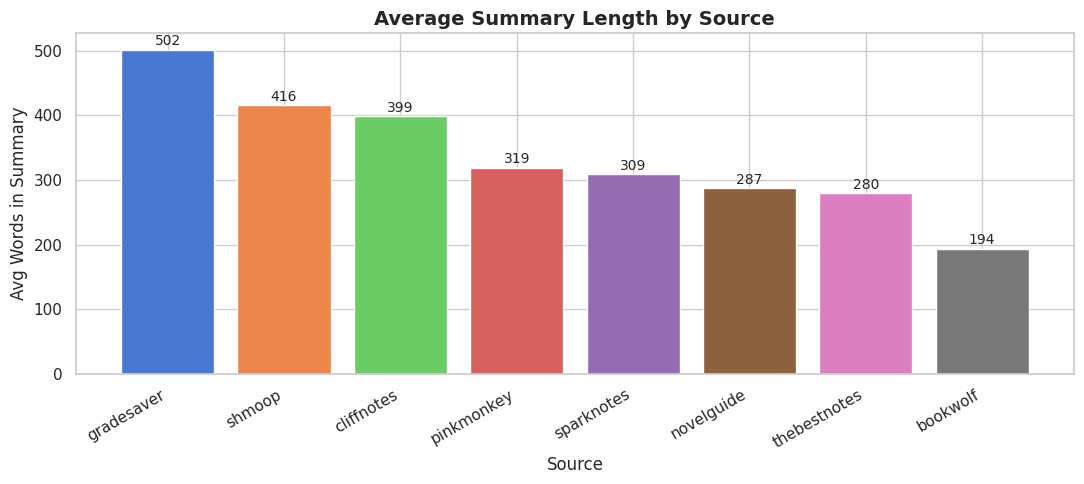

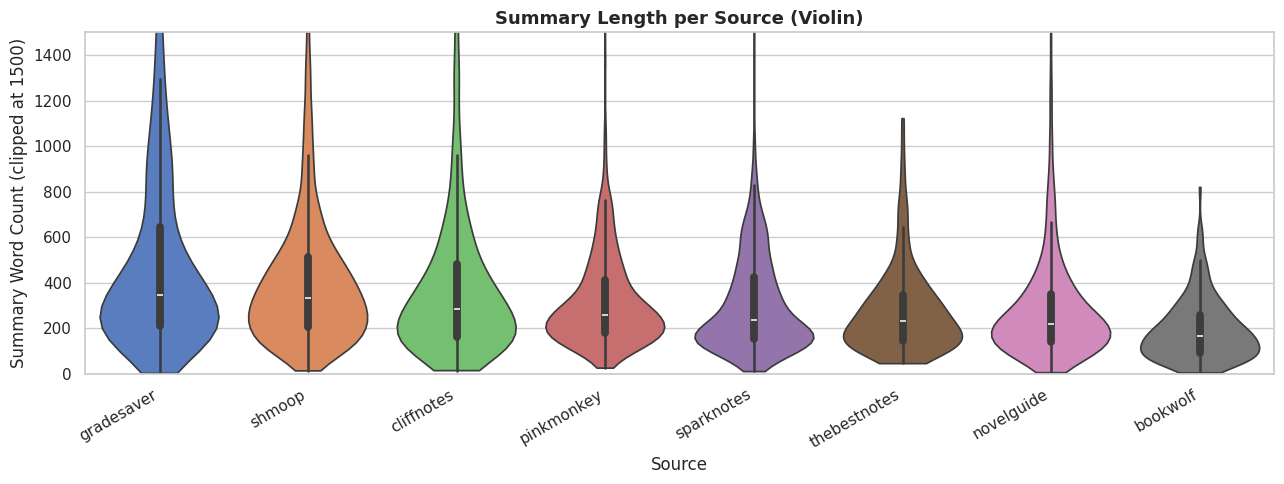

In [ ]:

src_stats = df_train.groupby('source').agg(
    count             =('summary_text',   'count'),
    avg_chapter_words =('chapter_words',  'mean'),
    avg_summary_words =('summary_words',  'mean'),
    median_summary    =('summary_words',  'median')
).round(0).astype(int)

print('\n=== Stats Per Source ===')
print(src_stats.to_string())

# Bar: average summary length per source
fig, ax = plt.subplots(figsize=(11, 5))
ss = src_stats.sort_values('avg_summary_words', ascending=False)
bars = ax.bar(ss.index, ss['avg_summary_words'],
              color=sns.color_palette('muted', len(ss)), edgecolor='white')
ax.set_title('Average Summary Length by Source', fontsize=14, fontweight='bold')
ax.set_xlabel('Source')
ax.set_ylabel('Avg Words in Summary')
ax.set_xticklabels(ss.index, rotation=30, ha='right')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('fig_06_avg_summary_by_source.png', dpi=120)
plt.show()

# Violin: summary length per source
fig, ax = plt.subplots(figsize=(13, 5))
src_order = (df_train.groupby('source')['summary_words']
             .median().sort_values(ascending=False).index)
sns.violinplot(data=df_train, x='source', y='summary_words',
               order=src_order, palette='muted', ax=ax, cut=0)
ax.set_ylim(0, 1500)
ax.set_title('Summary Length per Source (Violin)', fontsize=13, fontweight='bold')
ax.set_xlabel('Source')
ax.set_ylabel('Summary Word Count (clipped at 1500)')
ax.set_xticklabels(src_order, rotation=30, ha='right')
plt.tight_layout()
plt.savefig('fig_07_violin_by_source.png', dpi=120)
plt.show()


> gradesaver produces the longest summaries on average (502 words), nearly 2.6x longer than bookwolf (194 words). This significant
difference means that ROUGE scores will vary depending on the source
of the reference summary — a factor that should be considered when
interpreting model evaluation results.

### 2.5 Aggregate VS Non-Aggregate Deep Dive


Aggregate rows have significantly longer chapters (avg 9,679 words)
and summaries (avg 675 words) compared to non-aggregate rows
(avg 2,912 and 318 words respectively). cliffnotes has the highest
aggregate rate at 37.9%, meaning it will lose the most rows after
filtering. shmoop has the lowest at 2.6%.

In [ ]:

agg_grp = df_train.groupby('is_aggregate').agg(
    count             =('chapter',       'count'),
    avg_chapter_words =('chapter_words', 'mean'),
    avg_summary_words =('summary_words', 'mean'),
    max_chapter_words =('chapter_words', 'max')
).round(0)

print('\n=== Aggregate vs Non-Aggregate Comparison ===')
print(agg_grp.to_string())
print('\n Aggregate rows have much longer texts — they cover multiple chapters.')

agg_by_src = (df_train.groupby(['source', 'is_aggregate'])
              .size().unstack(fill_value=0))
agg_by_src['agg_rate%'] = (
    agg_by_src[True] / agg_by_src.sum(axis=1) * 100
).round(1)

print('\n=== Aggregate Rate per Source ===')
print(agg_by_src.to_string())


=== Aggregate vs Non-Aggregate Comparison ===
              count  avg_chapter_words  avg_summary_words  max_chapter_words
is_aggregate                                                                
False          8027             2912.0              318.0              31431
True           1573             9679.0              675.0             114455

 Aggregate rows have much longer texts — they cover multiple chapters.

=== Aggregate Rate per Source ===
is_aggregate  False  True  agg_rate%
source                              
bookwolf        143    59       29.2
cliffnotes      791   483       37.9
gradesaver     1040   412       28.4
novelguide     1014   177       14.9
pinkmonkey      944    65        6.4
shmoop         2758    74        2.6
sparknotes     1054   292       21.7
thebestnotes    283    11        3.7


### 2.6 Text Quality Checks


We check for common data quality issues: very short texts, duplicates,
encoding errors, and empty strings. The data is largely clean —
only 1 chapter under 50 words and 4 summaries under 10 words were
found. Notably, 4,868 duplicate chapters exist because the same
chapter appears with summaries from multiple sources, which is
intentional in the dataset design.

In [ ]:

# Very short texts
short_ch  = df_train[df_train['chapter_words']  < 50]
short_sum = df_train[df_train['summary_words'] < 10]
print(f'\nChapters  < 50 words:  {len(short_ch)}'
      f' ({len(short_ch)/len(df_train)*100:.2f}%)')
print(f'Summaries < 10 words: {len(short_sum)}'
      f' ({len(short_sum)/len(df_train)*100:.2f}%)')

if len(short_sum) > 0:
    print('\n=== Sample Short Summaries ===')
    print(short_sum[['book_id','summary_text','summary_words']].head(5).to_string())

# Exact duplicates
dup_ch  = df_train.duplicated(subset=['chapter']).sum()
dup_sum = df_train.duplicated(subset=['summary_text']).sum()
print(f'\nDuplicate chapters:  {dup_ch}')
print(f'Duplicate summaries: {dup_sum}')

# Encoding / control characters
def has_encoding_issues(text):
    if not isinstance(text, str):
        return False
    return bool(re.search(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]', text))

enc_issues = df_train['chapter'].apply(has_encoding_issues).sum()
print(f'Chapters with control characters: {enc_issues}')

# Empty strings (not NaN)
empty_ch  = (df_train['chapter'].str.strip()      == '').sum()
empty_sum = (df_train['summary_text'].str.strip() == '').sum()
print(f'\nEmpty chapter strings:  {empty_ch}')
print(f'Empty summary strings:  {empty_sum}')



Chapters  < 50 words:  1 (0.01%)
Summaries < 10 words: 4 (0.04%)

=== Sample Short Summaries ===
                            book_id                                        summary_text  summary_words
2755   Wuthering Heights.chapter 25                                          Chapter 25              2
3266  Mansfield Park.chapters 17-24               Chapter Eighteen and Chapter Nineteen              5
5165          Othello.act 3.scene 2     Othello's business takes shorter than expected.              6
7367          Macbeth.act 5.scene 6  Malcolm's army under camouflage reaches Dunsinane.              6

Duplicate chapters:  4868
Duplicate summaries: 97
Chapters with control characters: 0

Empty chapter strings:  0
Empty summary strings:  0


The dataset is largely clean. Only 1 chapter under 50 words and
4 summaries under 10 words were found — all of which are clearly
malformed entries (e.g. summary_text = "Chapter 25"). No encoding
issues or empty strings were detected. The 4,868 duplicate chapters
are intentional — the same chapter appears with different summaries
from different sources, which is by design in the BookSum dataset.

### 2.7 Compression Ratio Analysis


Compression ratio is defined as summary_words / chapter_words.
The median ratio is 0.10, meaning summaries are approximately 10%
the length of their source chapters. bookwolf has the highest
compression (median 0.063) while shmoop has the lowest (median 0.128).
Chapters with higher compression ratios tend to be shorter, as seen
in the scatter plot.


=== Compression Ratio Stats ===
count    9600.0000
mean        0.1532
std         0.2148
min         0.0002
25%         0.0594
50%         0.0995
75%         0.1762
max         7.7181
Name: compression_ratio, dtype: float64

💡 Median CR: 0.100  →  for every 1000-word chapter, summary ≈ 99 words


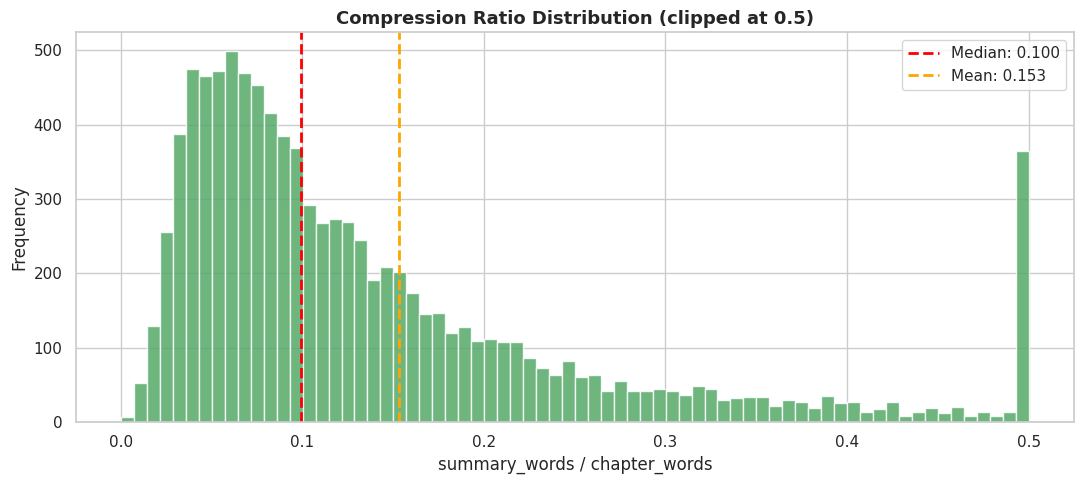


=== Compression Ratio per Source (lower = more compressed) ===
              Mean CR  Median CR
source                          
bookwolf        0.121      0.063
sparknotes      0.126      0.074
cliffnotes      0.138      0.076
novelguide      0.127      0.077
thebestnotes    0.120      0.093
gradesaver      0.135      0.104
pinkmonkey      0.207      0.120
shmoop          0.180      0.128


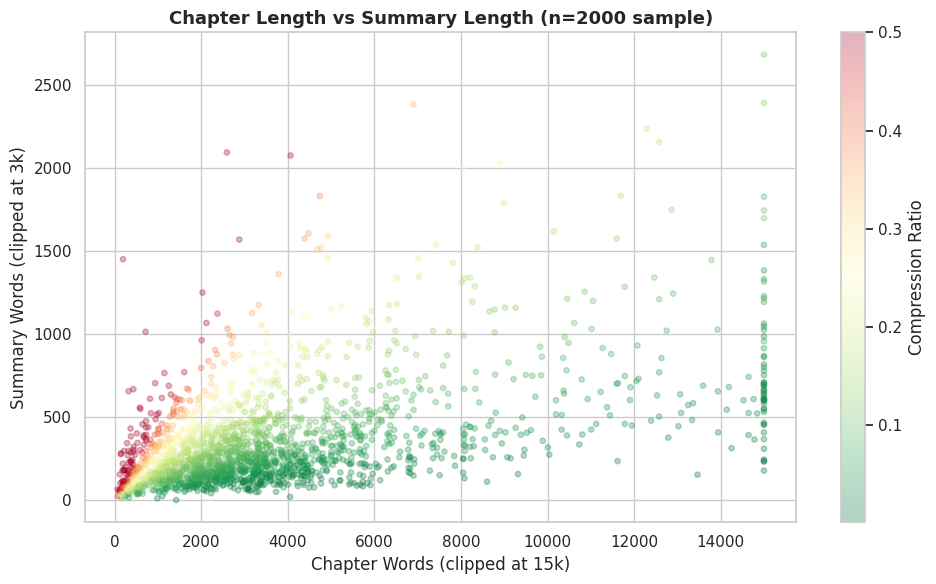

In [ ]:
# Compression Ratio = summary_words / chapter_words
# Lower = more compressed (shorter summary relative to chapter)

df_train['compression_ratio'] = (
    df_train['summary_words'] / df_train['chapter_words']
)

print('\n=== Compression Ratio Stats ===')
print(df_train['compression_ratio'].describe().round(4))

med_cr = df_train['compression_ratio'].median()
print(f'\n💡 Median CR: {med_cr:.3f}'
      f'  →  for every 1000-word chapter, summary ≈ {int(med_cr*1000)} words')

# Histogram
fig, ax = plt.subplots(figsize=(11, 5))
df_train['compression_ratio'].clip(upper=0.5).hist(
    bins=70, ax=ax, color='#55A868', edgecolor='white', alpha=0.85)
ax.axvline(med_cr, color='red', linestyle='--', linewidth=2,
           label=f'Median: {med_cr:.3f}')
ax.axvline(df_train['compression_ratio'].mean(), color='orange',
           linestyle='--', linewidth=2,
           label=f'Mean: {df_train["compression_ratio"].mean():.3f}')
ax.set_title('Compression Ratio Distribution (clipped at 0.5)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('summary_words / chapter_words')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('fig_08_compression_ratio.png', dpi=120)
plt.show()

# Per source
print('\n=== Compression Ratio per Source (lower = more compressed) ===')
cr_src = (df_train.groupby('source')['compression_ratio']
          .agg(['mean', 'median']).round(3))
cr_src.columns = ['Mean CR', 'Median CR']
print(cr_src.sort_values('Median CR').to_string())

# Scatter: chapter length vs summary length (coloured by CR)
fig, ax = plt.subplots(figsize=(10, 6))
sample = df_train.sample(min(2000, len(df_train)), random_state=42)
sc = ax.scatter(
    sample['chapter_words'].clip(upper=15000),
    sample['summary_words'].clip(upper=3000),
    alpha=0.3,
    c=sample['compression_ratio'].clip(upper=0.5),
    cmap='RdYlGn_r', s=15
)
plt.colorbar(sc, label='Compression Ratio')
ax.set_title('Chapter Length vs Summary Length (n=2000 sample)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Chapter Words (clipped at 15k)')
ax.set_ylabel('Summary Words (clipped at 3k)')
plt.tight_layout()
plt.savefig('fig_09_scatter_cr.png', dpi=120)
plt.show()


The median compression ratio of 0.10 means summaries are approximately
10% the length of their source chapters on average. bookwolf applies
the most compression (median CR=0.063) while shmoop applies the least
(median CR=0.128). The scatter plot shows that shorter chapters tend
to have higher compression ratios, meaning their summaries are
proportionally longer relative to the chapter. One outlier with
CR=7.18 was detected, likely an aggregate row that passed filtering
or a data entry error.

### 2.8 Sample Inspection — Reading Actual Text


We read actual chapter-summary pairs to understand the data quality
and writing style across sources. shmoop writes the most detailed
summaries (880 words for a 4,922-word chapter), while sparknotes
is the most concise (154 words for a 5,078-word chapter). All
inspected samples are fiction, consistent with the genre imbalance
observed in Section 4c.

In [ ]:

def show_sample(row, max_chars=500):
    print('=' * 70)
    print(f'Book:        {row.get("book_id", "N/A")}')
    print(f'Source:      {row["source"]}')
    print(f'Aggregate:   {row["is_aggregate"]}')
    print(f'Chapter:     {row["chapter_words"]:,} words')
    print(f'Summary:     {row["summary_words"]:,} words')
    print(f'Compression: {row["compression_ratio"]:.3f}')
    print('─' * 70)
    print('CHAPTER (first 500 chars):')
    print(str(row['chapter'])[:max_chars] + ' ...')
    print('─' * 70)
    print('SUMMARY TEXT (first 500 chars):')
    print(str(row['summary_text'])[:max_chars] + ' ...')
    if pd.notna(row.get('summary_analysis')):
        print('─' * 70)
        print('ANALYSIS (first 300 chars):')
        print(str(row['summary_analysis'])[:300] + ' ...')
    print('=' * 70)


# Median-length sample
median_idx = (
    df_train['chapter_words'] - df_train['chapter_words'].median()
).abs().idxmin()
print('\n### SAMPLE: MEDIAN LENGTH CHAPTER ###')
show_sample(df_train.loc[median_idx])

# Longest chapter
longest_idx = df_train['chapter_words'].idxmax()
print(f'\n### SAMPLE: LONGEST CHAPTER '
      f'({df_train.loc[longest_idx,"chapter_words"]:,} words) ###')
show_sample(df_train.loc[longest_idx])

# One sample per source
non_agg = df_train[df_train['is_aggregate'] == False]
for src in non_agg['source'].unique()[:4]:
    row = non_agg[non_agg['source'] == src].sample(1, random_state=42).iloc[0]
    print(f'\n### SOURCE: {src.upper()} ###')
    show_sample(row)




### SAMPLE: MEDIAN LENGTH CHAPTER ###
Book:        Emma.volume 3.chapter 48
Source:      gradesaver
Aggregate:   False
Chapter:     2,934 words
Summary:     84 words
Compression: 0.029
──────────────────────────────────────────────────────────────────────
CHAPTER (first 500 chars):


Till now that she was threatened with its loss, Emma had never known
how much of her happiness depended on being _first_ with Mr. Knightley,
first in interest and affection.--Satisfied that it was so, and feeling
it her due, she had enjoyed it without reflection; and only in the
dread of being supplanted, found how inexpressibly important it had
been.--Long, very long, she felt she had been first; for, having no
female connexions of his own, there had been only Isabella whose claims
could be c ...
──────────────────────────────────────────────────────────────────────
SUMMARY TEXT (first 500 chars):
Emma gives up hope that Mr. Knightley is in love with her. Even if he were, she would still not be able to m

## 3.PREPROCESSING PIPELINE


We apply a 8-step preprocessing pipeline to all three splits.
Step 1 removes aggregate rows. Steps 2-3 remove NaN and empty strings.
Step 4 normalizes unicode characters and whitespace. Step 5 removes
texts that are too short (chapter < 100 words, summary < 20 words), and the last step is reseting the indices.
The final sizes are: train 7,990 rows (83.2%), val 1,326 (89.4%),
and test 1,174 (82.0%).

In [ ]:
# Set device for GPU training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### 3.1 Text Cleaning Functions
We define helper functions to clean individual text strings by normalizing unicode, fixing whitespace, and removing control characters.

In [ ]:
def clean_text(text: str) -> str:
    """
    Clean a single text string by normalizing unicode, fixing whitespace,
    and removing control characters.

    Args:
        text: Input text string

    Returns:
        Cleaned text string
    """
    if not isinstance(text, str):
        return ""

    # Normalize unicode (e.g., convert fancy quotes to ASCII)
    text = unicodedata.normalize('NFKC', text)

    # Replace multiple whitespace characters with a single space
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove control characters (ASCII 0-31 and 127-159)
    text = ''.join(char for char in text if ord(char) >= 32 or char in '\n\r\t')

    return text

### 3.2 Full Preprocessing Pipeline
The complete pipeline performs the following steps in order:

- Remove aggregate rows (is_aggregate == True) - These cover multiple chapters
- Drop NaN in key columns (chapter, summary_text)
- Drop empty strings after stripping whitespace
- Clean text - Normalize unicode, fix whitespace, remove control chars
- Calculate cleaned word counts - For filtering based on length
- Remove too-short samples - Chapters < 100 words, summaries < 20 words
- Create combined text with source - For multimodal model input
- Reset index - Ensure clean sequential indexing

In [ ]:
def preprocess_pipeline(df: pd.DataFrame, split_name: str = 'train') -> pd.DataFrame:
    """
    Full preprocessing pipeline for one BookSum split.

    Steps
    ─────
    1. Remove aggregate rows        (is_aggregate == True)
    2. Drop NaN in key columns       (chapter, summary_text)
    3. Drop empty strings
    4. Clean text                    (unicode, whitespace, control chars)
    5. Calculate cleaned word counts (for filtering)
    6. Remove too-short samples      (chapter < 100 words, summary < 20 words)
    7. Create combined text with source (for multimodal model)
    8. Reset index
    """
    original_size = len(df)
    log = []

    # Step 1: Remove aggregate rows (multi-chapter summaries)
    df = df[df['is_aggregate'] == False].copy()
    log.append(('1. Remove aggregates', original_size - len(df), len(df)))

    # Step 2: Drop rows with NaN in essential columns
    before = len(df)
    df = df.dropna(subset=['chapter', 'summary_text'])
    log.append(('2. Drop NaN (chapter / summary_text)', before - len(df), len(df)))

    # Step 3: Drop empty strings (after stripping whitespace)
    before = len(df)
    df = df[
        (df['chapter'].str.strip()      != '') &
        (df['summary_text'].str.strip() != '')
    ]
    log.append(('3. Drop empty strings', before - len(df), len(df)))

    # Step 4: Clean text (normalize unicode, fix whitespace, remove control chars)
    df['chapter_clean'] = df['chapter'].apply(clean_text)
    df['summary_clean'] = df['summary_text'].apply(clean_text)
    log.append(('4. Clean text (unicode / whitespace)', 0, len(df)))

    # Step 5: Calculate word counts from cleaned text (for filtering)
    df['chapter_words_clean'] = df['chapter_clean'].str.split().str.len()
    df['summary_words_clean'] = df['summary_clean'].str.split().str.len()
    log.append(('5. Calculate cleaned word counts', 0, len(df)))

    # Step 6: Remove samples that are too short (min length thresholds)
    before = len(df)
    df = df[
        (df['chapter_words_clean'] >= 100) &
        (df['summary_words_clean'] >= 20)
    ]
    log.append(('6. Remove too-short (ch<100 / sum<20 words)', before - len(df), len(df)))

    # Step 7: Create combined text with source for multimodal model
    # Format: "[CHAPTER TEXT] [SEP] [SOURCE]"
    df['combined_text'] = df['chapter_clean'] + " [SEP] " + df['source']
    log.append(('7. Create combined text with source', 0, len(df)))

    # Step 8: Reset index to ensure clean sequential indexing
    df = df.reset_index(drop=True)
    log.append(('8. Reset index', 0, len(df)))

    # Print detailed preprocessing log
    print(f'\n{"═"*65}')
    print(f'  Preprocessing Log — {split_name}')
    print(f'{"═"*65}')
    print(f'  {"Step":<45} {"Removed":>8} {"Remaining":>10}')
    print(f'  {"─"*63}')
    for step, removed, remaining in log:
        print(f'  {step:<45} {removed:>8,} {remaining:>10,}')
    print(f'{"─"*65}')
    print(f'  Original: {original_size:,}  →  Final: {len(df):,}'
          f'  ({len(df)/original_size*100:.1f}% retained)')
    print(f'{"═"*65}')

    return df

### 3.3 Apply Pipeline to All Splits
We apply the preprocessing pipeline to training, validation, and test sets separately. This ensures consistent cleaning across all data while maintaining the separation between splits.

In [ ]:
df_train_clean = preprocess_pipeline(df_train, 'train')
df_val_clean = preprocess_pipeline(df_val, 'validation')
df_test_clean = preprocess_pipeline(df_test, 'test')

print(f"  Train: {df_train_clean.shape}")
print(f"  Val:   {df_val_clean.shape}")
print(f"  Test:  {df_test_clean.shape}")


═════════════════════════════════════════════════════════════════
  Preprocessing Log — train
═════════════════════════════════════════════════════════════════
  Step                                           Removed  Remaining
  ───────────────────────────────────────────────────────────────
  1. Remove aggregates                             1,573      8,027
  2. Drop NaN (chapter / summary_text)                 0      8,027
  3. Drop empty strings                                0      8,027
  4. Clean text (unicode / whitespace)                 0      8,027
  5. Calculate cleaned word counts                     0      8,027
  6. Remove too-short (ch<100 / sum<20 words)         37      7,990
  7. Create combined text with source                  0      7,990
  8. Reset index                                       0      7,990
─────────────────────────────────────────────────────────────────
  Original: 9,600  →  Final: 7,990  (83.2% retained)
══════════════════════════════════════════

## 4.CHUNKING

Since 96% of chapters exceed BERT's token limit, we apply hierarchical
sentence-aware chunking to all chapters across all splits. Each chunk
contains a maximum of 350 words with a 50-word sentence-level overlap
to preserve context across boundaries. The average chapter produces
10.6 chunks, with the majority of chapters requiring between 6 and
14 chunks.

### 4.1 Sentence-Aware Chunking Function

In [ ]:
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize
import matplotlib.pyplot as plt

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!



Applying hierarchical chunking to train split...

=== Chunk Count Stats (BERT, 350-word window) ===
count    7990.0
mean       10.1
std         6.6
min         1.0
25%         6.0
50%         9.0
75%        13.0
max       100.0
Name: num_chunks_bert, dtype: float64

Chapters needing 1 chunk:    287
Chapters needing 2–5 chunks: 1,696
Chapters needing 6+ chunks:  6,007


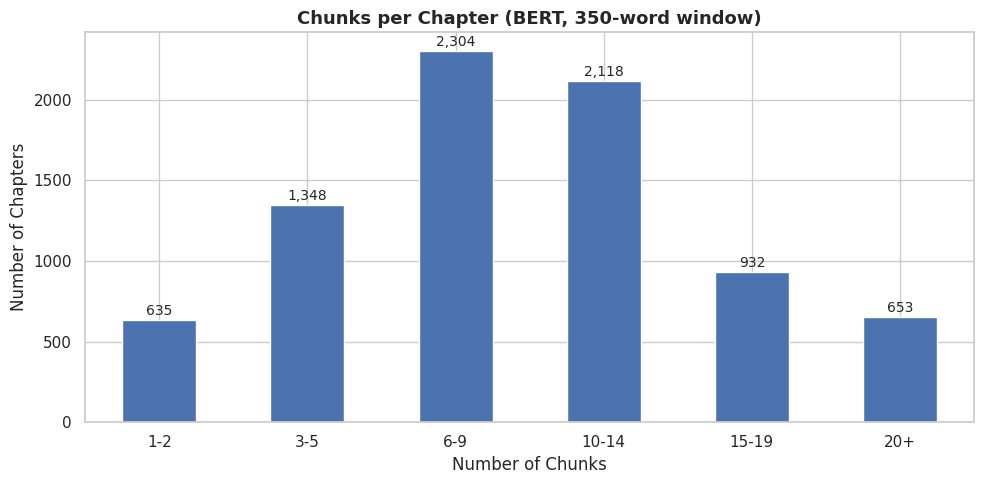


── Chunking Demo ──
Book:          A Vindication of the Rights of Woman.chapter 6
Chapter words: 2,592
Num chunks:    9

--- Chunk 1 (first 250 chars) ---
Educated in the enervating style recommended by the writers on whom I have been animadverting; and not having a chance, from their subordinate state in society, to recover their lost ground, is it surprising that women every where appear a defect in  ...

--- Chunk 2 (first 250 chars — notice overlap) ---
These fine intractable spirits appear to be the essence of genius, and beaming in its eagle eye, produce in the most eminent degree the happy energy of associating thoughts that surprise, delight, and instruct. These are the glowing minds that concen ...


In [ ]:

def hierarchical_chunks(text: str,
                         max_words: int = 350,
                         overlap_words: int = 50) -> list:
    """
        Sentence-aware sliding window chunking.

    Why sentence-aware?
      Splitting mid-sentence breaks grammar and confuses the encoder.
      This function respects sentence boundaries while keeping each
      chunk within the word budget.

    Parameters
    ──────────
    text          : cleaned chapter text
    max_words     : maximum words per chunk
                    BERT  → 350  (≈ 512 tokens with special tokens)
                    LED   → 3000 (≈ 4096 tokens)
    overlap_words : words carried over from previous chunk (context window)

    Returns
    ───────
    List of text chunks.
    """
    sentences = sent_tokenize(text)
    chunks        = []
    current_sents = []
    wc            = 0

    for sent in sentences:
        sw = sent.split()

        if wc + len(sw) > max_words and current_sents:
            #  Save current chunk
            chunks.append(' '.join(
                w for s in current_sents for w in s.split()
            ))

            #  overlap: taking full sentences from the end
            overlap_sents = []
            overlap_wc    = 0
            for s in reversed(current_sents):
                s_words = s.split()
                if overlap_wc + len(s_words) <= overlap_words:
                    overlap_sents.insert(0, s)
                    overlap_wc += len(s_words)
                else:
                    break

            current_sents = overlap_sents
            wc            = overlap_wc

        current_sents.append(sent)
        wc += len(sw)

    if current_sents:
        chunks.append(' '.join(
            w for s in current_sents for w in s.split()
        ))

    return chunks if chunks else [text]

# Apply chunking (BERT-compatible: 350-word windows)
print('\nApplying hierarchical chunking to train split...')
df_train_clean['chunks_bert']     = df_train_clean['chapter_clean'].apply(
    lambda x: hierarchical_chunks(x, max_words=350, overlap_words=50)
)
df_train_clean['num_chunks_bert'] = df_train_clean['chunks_bert'].apply(len)

print('\n=== Chunk Count Stats (BERT, 350-word window) ===')
print(df_train_clean['num_chunks_bert'].describe().round(1))

n1   = (df_train_clean['num_chunks_bert'] == 1).sum()
n2_5 = ((df_train_clean['num_chunks_bert'] >= 2) &
         (df_train_clean['num_chunks_bert'] <= 5)).sum()
n6p  = (df_train_clean['num_chunks_bert'] >= 6).sum()
print(f'\nChapters needing 1 chunk:    {n1:,}')
print(f'Chapters needing 2–5 chunks: {n2_5:,}')
print(f'Chapters needing 6+ chunks:  {n6p:,}')

# Visualize chunk distribution with ranges
fig, ax = plt.subplots(figsize=(10, 5))

bins = [1, 3, 6, 10, 15, 20, float('inf')]
labels = ['1-2', '3-5', '6-9', '10-14', '15-19', '20+']

df_train_clean['chunk_range'] = pd.cut(
    df_train_clean['num_chunks_bert'],
    bins=bins,
    labels=labels,
    right=False
)

range_counts = df_train_clean['chunk_range'].value_counts().sort_index()
range_counts.plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='white')

ax.set_title('Chunks per Chapter (BERT, 350-word window)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Chunks')
ax.set_ylabel('Number of Chapters')
ax.set_xticklabels(labels, rotation=0)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 10,
            f'{int(p.get_height()):,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('fig_10_chunks_per_chapter.png', dpi=120)
plt.show()

# Demo: show one sample with its chunks
sample_idx = (
    df_train_clean['chapter_words_clean']
    .sub(df_train_clean['chapter_words_clean'].median())
    .abs().idxmin()
)
row = df_train_clean.loc[sample_idx]
print(f'\n── Chunking Demo ──')
print(f'Book:          {row.get("book_id","N/A")}')
print(f'Chapter words: {row["chapter_words_clean"]:,}')
print(f'Num chunks:    {row["num_chunks_bert"]}')
print(f'\n--- Chunk 1 (first 250 chars) ---')
print(row['chunks_bert'][0][:250] + ' ...')
if len(row['chunks_bert']) > 1:
    print(f'\n--- Chunk 2 (first 250 chars — notice overlap) ---')
    print(row['chunks_bert'][1][:250] + ' ...')


### 4.2 Apply Chunking to All Splits

In [ ]:
#  Apply chunking to val and test splits
print('Applying chunking to validation split...')
df_val_clean['chunks_bert']     = df_val_clean['chapter_clean'].apply(
    lambda x: hierarchical_chunks(x, max_words=350, overlap_words=50)
)
df_val_clean['num_chunks_bert'] = df_val_clean['chunks_bert'].apply(len)

print('Applying chunking to test split...')
df_test_clean['chunks_bert']     = df_test_clean['chapter_clean'].apply(
    lambda x: hierarchical_chunks(x, max_words=350, overlap_words=50)
)
df_test_clean['num_chunks_bert'] = df_test_clean['chunks_bert'].apply(len)


Applying chunking to validation split...
Applying chunking to test split...



> Chunking was applied to all three splits. The training set produced an average of 10.1 chunks per chapter (min=1, max=100). The majority
of chapters (4,422 out of 7,990) require between 6 and 14 chunks.
Only 635 chapters needed 1-2 chunks. This is consistent with the
finding in Section 5 that 96% of chapters exceed BERT's token limit
of ~380 words, requiring the majority of chapters to be split into
multiple chunks before processing.The sentence-aware overlap ensures
that no sentence is split mid-way between chunks, preserving semantic
continuity across chunk boundaries.

## 5.POST-PROCESSING VALIDATION


We run a final validation check across all three splits to confirm
the preprocessing is correct. All 8 checks passed: correct row counts,
zero aggregate rows, zero NaN, zero empty strings, minimum length
thresholds met, valid chunks for all chapters, all required columns
present, and valid compression ratios.

In [ ]:

print('\n=== POST-PROCESSING VALIDATION ===')

assert df_train_clean['is_aggregate'].sum() == 0, \
    '❌ Aggregate rows still present!'
print('No aggregate rows')

assert df_train_clean['chapter_clean'].isna().sum() == 0, \
    '❌ NaN in chapter_clean!'
assert df_train_clean['summary_clean'].isna().sum() == 0, \
    '❌ NaN in summary_clean!'
print('No NaN in chapter_clean / summary_clean')

assert (df_train_clean['chapter_clean'].str.strip() == '').sum() == 0, \
    '❌ Empty chapter strings found!'
print('No empty strings')

assert (df_train_clean['num_chunks_bert'] == 0).sum() == 0, \
    '❌ Chapters with 0 chunks found!'
print('All chapters have at least 1 chunk')

assert df_train_clean['summary_words_clean'].min() >= 20, \
    '❌ Summaries shorter than 20 words found!'
print('All summaries ≥ 20 words')

print('\nAll validation checks passed!')

# Before vs after comparison
print('\n=== BEFORE vs AFTER (Train) ===')
print(f'  Rows:           {len(df_train):>7,}  →  {len(df_train_clean):>7,}')
print(f'  Avg ch. words:  {df_train["chapter_words"].mean():>7.0f}  →  '
      f'{df_train_clean["chapter_words_clean"].mean():>7.0f}')
print(f'  Avg sum. words: {df_train["summary_words"].mean():>7.0f}  →  '
      f'{df_train_clean["summary_words_clean"].mean():>7.0f}')



=== POST-PROCESSING VALIDATION ===
No aggregate rows
No NaN in chapter_clean / summary_clean
No empty strings
All chapters have at least 1 chunk
All summaries ≥ 20 words

All validation checks passed!

=== BEFORE vs AFTER (Train) ===
  Rows:             9,600  →    7,990
  Avg ch. words:     4021  →     2924
  Avg sum. words:     377  →      320



> The validation confirms that our preprocessing pipeline worked as intended:
> - All aggregate rows (1,573 from training) were successfully removed
> - No missing values or empty strings remain in the text columns
> - The minimum length thresholds (100 words for chapters, 20 for summaries) are enforced
> - Every chapter has been properly chunked into at least one segment
> - The average chapter length dropped from 4,021 to 2,924 words, reflecting the removal of very long aggregate chapters



## 6.SAVE PROCESSED DATA


Finally, we save the cleaned and chunked datasets to Google Drive for
future use in model training. We use the parquet format because it
preserves list types (like the chunks) correctly.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#  Set save path in Google Drive
SAVE_PATH = '/content/drive/MyDrive/BookSum_Project/'

import os
os.makedirs(SAVE_PATH, exist_ok=True)

#  Add compression ratio to all splits
for df, name in [(df_train_clean, 'train'),
                 (df_val_clean,   'val'),
                 (df_test_clean,  'test')]:
    df['compression_ratio'] = (
        df['summary_words_clean'] / df['chapter_words_clean']
    )

#  Select columns to save
COLS = [
    'bid', 'book_id', 'source',
    'chapter_clean', 'summary_clean',
    'chapter_words_clean', 'summary_words_clean',
    'compression_ratio',
    'chunks_bert', 'num_chunks_bert'
]

#  Save as parquet (preserves list types correctly)
df_train_clean[COLS].to_parquet(SAVE_PATH + 'booksum_train.parquet', index=False)
df_val_clean[COLS].to_parquet(  SAVE_PATH + 'booksum_val.parquet',   index=False)
df_test_clean[COLS].to_parquet( SAVE_PATH + 'booksum_test.parquet',  index=False)

print('Saved to Google Drive:')
print(f'  {SAVE_PATH}booksum_train.parquet  → {len(df_train_clean):,} rows')
print(f'  {SAVE_PATH}booksum_val.parquet    → {len(df_val_clean):,} rows')
print(f'  {SAVE_PATH}booksum_test.parquet   → {len(df_test_clean):,} rows')

#  Verify save
test_load = pd.read_parquet(SAVE_PATH + 'booksum_train.parquet')

# parquet may load lists as numpy arrays — both are acceptable
first_val = test_load['chunks_bert'].iloc[0]
assert isinstance(first_val, (list, np.ndarray)), \
    '❌ chunks_bert did not load correctly!'

print('\n Verification passed — chunks_bert loaded correctly')
print(f'   Type: {type(first_val).__name__}')
print(f'   First chunk preview: {first_val[0][:100]}...')
print(f'\nShape: {test_load.shape}')

Saved to Google Drive:
  /content/drive/MyDrive/BookSum_Project/booksum_train.parquet  → 7,990 rows
  /content/drive/MyDrive/BookSum_Project/booksum_val.parquet    → 1,326 rows
  /content/drive/MyDrive/BookSum_Project/booksum_test.parquet   → 1,174 rows

 Verification passed — chunks_bert loaded correctly
   Type: ndarray
   First chunk preview: "Before these fields were shorn and tilled, Full to the brim our rivers flowed; The melody of waters...

Shape: (7990, 10)


## 7.BERT EXTRACTIVE MODEL


In [2]:
from google.colab import drive
drive.mount('/content/drive')

df_train_clean = pd.read_parquet('/content/drive/MyDrive/BookSum_Project/booksum_train.parquet')
df_val_clean = pd.read_parquet('/content/drive/MyDrive/BookSum_Project/booksum_val.parquet')
df_test_clean = pd.read_parquet('/content/drive/MyDrive/BookSum_Project/booksum_test.parquet')

Mounted at /content/drive


## 7.1 Model Architecture

**Architecture:**
- Using pre-trained DistilBERT 'distilbert-base-uncased' (6-layer, 768-d CLS embeddings)
- Extractive summarization: split text into sentences, encode each sentence
  independently, compute mean document embedding, rank sentences by cosine
  similarity, select top-N representative sentences in original order
- GPU used if available for faster computation

**Parameters:**
- num_sentences = 3 (number of sentences in summary)
- Max chapter length during evaluation = 2000 characters
- ROUGE evaluation types: rouge1, rouge2, rougeL
- Additional metrics: BERTScore F1, Extractive Ratio
- Output: CSV with generated summaries and reference summaries,
  plus average summary length


In [5]:
# Install required libraries
!pip install sentence-transformers evaluate rouge-score bert-score -q

import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
import os
import warnings
warnings.filterwarnings('ignore')

from transformers import DistilBertTokenizer, DistilBertModel
import torch

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# ============= 1. LOAD DISTILBERT MODEL =============

print("\n" + "="*60)
print("Loading DistilBERT Model for Extractive Summarization")
print("="*60)

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased').to(device)

# ============= 2. SPLIT INTO SENTENCES =============

import re

def split_sentences(text):
    # Split on sentence-ending punctuation followed by whitespace
    sentences = re.split(r'(?<=[.!?]) +', text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

# ============= 3. DISTILBERT EXTRACTIVE SUMMARIZER =============

def summarize_with_bert(chapter_text, source=None, num_sentences=3):
    sentences = split_sentences(chapter_text)

    if len(sentences) == 0:
        return ""

    embeddings = []
    for sent in sentences:
        # Tokenize with truncation to 512 tokens
        inputs = tokenizer(
            sent,
            return_tensors='pt',
            truncation=True,
            max_length=512,
            padding=True
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        # CLS token as sentence embedding (768-dimensional for DistilBERT)
        emb = outputs.last_hidden_state[:, 0, :]
        embeddings.append(emb.squeeze())

    embeddings = torch.stack(embeddings)

    # Compute mean document embedding then rank by cosine similarity
    doc_embedding = embeddings.mean(dim=0)
    scores = torch.nn.functional.cosine_similarity(
        embeddings, doc_embedding.unsqueeze(0)
    )

    # Select top-N sentences and preserve original order
    ranked_idx = scores.argsort(descending=True)
    selected = sorted(ranked_idx[:num_sentences].cpu().numpy())
    summary = " ".join([sentences[i] for i in selected])

    return summary

# ============= 4. ROUGE EVALUATION =============

def evaluate_rouge(predictions, references):
    try:
        from evaluate import load
        rouge = load('rouge')

        results = rouge.compute(
            predictions=predictions,
            references=references,
            rouge_types=['rouge1', 'rouge2', 'rougeL']
        )
        return results
    except Exception as e:
        print(f"Error calculating ROUGE: {e}")
        return None

# ============= 4.1 BERTSCORE EVALUATION =============

def evaluate_bertscore(predictions, references):
    # Semantic similarity using contextual embeddings (goes beyond lexical overlap)
    from bert_score import score
    P, R, F1 = score(
        predictions,
        references,
        lang="en",
        model_type="distilbert-base-uncased",
        device=device,
        verbose=False
    )
    return {
        'bertscore_precision': P.mean().item(),
        'bertscore_recall':    R.mean().item(),
        'bertscore_f1':        F1.mean().item()
    }

# ============= 4.2 EXTRACTIVE RATIO =============

def extractive_ratio(prediction, source):
    # Fraction of generated sentences copied directly from the source
    pred_sentences   = set(split_sentences(prediction.lower()))
    source_sentences = set(split_sentences(source.lower()))
    if len(pred_sentences) == 0:
        return 0.0
    copied = pred_sentences & source_sentences
    return len(copied) / len(pred_sentences)

# ============= 5. TEST SAMPLE =============

print("\n" + "="*60)
print("TESTING DISTILBERT ON SAMPLE")
print("="*60)

sample_row  = df_test_clean.iloc[0]
sample_text = sample_row['chapter_clean'][:1000]

print(f"\nSample Text:")
print(sample_text[:300] + "...")

summary = summarize_with_bert(sample_text, num_sentences=3)

print("\nGENERATED SUMMARY:")
print(summary)

print("\nREFERENCE SUMMARY:")
print(sample_row['summary_clean'][:500])

# ============= 6. BATCH EVALUATION =============

print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

eval_size = len(df_test_clean)
eval_samples = df_test_clean.head(eval_size).copy()

predictions       = []
references        = []
extractive_ratios = []

for idx, row in tqdm(eval_samples.iterrows(), total=len(eval_samples)):
    chapter = row['chapter_clean']

    # Truncate long chapters to first 2000 characters
    if len(chapter) > 2000:
        chapter = chapter[:2000]

    # Use BERT chunks if available
    if 'chunks_bert' in row.index and row['chunks_bert'] is not None:
        chunks = row['chunks_bert']
        if isinstance(chunks, (list, tuple)) and len(chunks) > 0:
            chapter = chunks[0]

    summary = summarize_with_bert(chapter, num_sentences=3)

    predictions.append(summary)
    references.append(row['summary_clean'])

    # Compute extractive ratio per sample
    extractive_ratios.append(extractive_ratio(summary, chapter))

# ============= 7. ROUGE SCORES =============

print("\nCalculating ROUGE scores...")
rouge_scores = evaluate_rouge(predictions, references)

if rouge_scores:
    print("\nROUGE SCORES:")
    print(f"ROUGE-1: {rouge_scores['rouge1']:.4f}")
    print(f"ROUGE-2: {rouge_scores['rouge2']:.4f}")
    print(f"ROUGE-L: {rouge_scores['rougeL']:.4f}")

# ============= 7.1 BERTSCORE =============

print("\nCalculating BERTScore...")
bert_scores = evaluate_bertscore(predictions, references)

print("\nBERTSCORE:")
print(f"Precision : {bert_scores['bertscore_precision']:.4f}")
print(f"Recall    : {bert_scores['bertscore_recall']:.4f}")
print(f"F1        : {bert_scores['bertscore_f1']:.4f}")

# ============= 7.2 EXTRACTIVE RATIO =============

avg_extractive_ratio = np.mean(extractive_ratios)
print(f"\nEXTRACTIVE RATIO: {avg_extractive_ratio:.4f}")
print("(1.0 = fully copied from source, 0.0 = fully generated)")

# ============= 8. SAVE RESULTS =============

output_dir = '/content/drive/MyDrive/BookSum_Project_DistilBERT_results'
os.makedirs(output_dir, exist_ok=True)

# Compute all per-sample BERTScores in a single batch call
from bert_score import score as bert_score_fn

_, _, F1_all = bert_score_fn(
    predictions,
    references,
    lang="en",
    model_type="distilbert-base-uncased",
    device=device,
    verbose=False
)
per_sample_bertscore = F1_all.tolist()

eval_samples['generated_summary'] = predictions
eval_samples['extractive_ratio']  = extractive_ratios
eval_samples['bertscore_f1']      = per_sample_bertscore

output_path = f'{output_dir}/distilbert_summaries.csv'
eval_samples[[
    'book_id',
    'generated_summary',
    'summary_clean',
    'extractive_ratio',
    'bertscore_f1'
]].to_csv(output_path, index=False)

print(f"\nResults saved to: {output_path}")

Using device: cuda

Loading DistilBERT Model for Extractive Summarization


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



TESTING DISTILBERT ON SAMPLE

Sample Text:
It is necessary to consider another point in examining the character of these principalities: that is, whether a prince has such power that, in case of need, he can support himself with his own resources, or whether he has always need of the assistance of others. And to make this quite clear I say t...

GENERATED SUMMARY:
It is necessary to consider another point in examining the character of these principalities: that is, whether a prince has such power that, in case of need, he can support himself with his own resources, or whether he has always need of the assistance of others. And to make this quite clear I say that I consider those who are able to support themselves by their own resources who can, either by abundance of men or money, raise a sufficient army to join battle against any one who comes to attack them; and I consider those always to have need of others who cannot show themselves against the enemy in the field, but are forced t

100%|██████████| 1174/1174 [01:27<00:00, 13.35it/s]


...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



BERTSCORE:
Precision : 0.7349
Recall    : 0.6996
F1        : 0.7163

EXTRACTIVE RATIO: 1.0000
(1.0 = fully copied from source, 0.0 = fully generated)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Results saved to: /content/drive/MyDrive/BookSum_Project_DistilBERT_results/distilbert_summaries.csv
